## Predictive Analytics — Fase 3: Construcción y Evaluación de Modelos Regularizados de Churn
**Presentado por:** Claudia Viviana Orozco Morera  
**Asesora:** Mireya García  
**Analítica Predictiva 203008078_3**  
**Universidad Nacional Abierta y a Distancia (UNAD)**  
**Especialización en Ciencia de Datos y Analítica — 2026**

---
## Contexto

Este notebook desarrolla íntegramente los cinco ejercicios de la Fase 3, partiendo de los resultados de la **Fase 2**, donde se construyó un conjunto de datos a nivel de cliente a partir de un dataset de comercio electrónico (UK Online Retail). Las características seleccionadas son:

| Variable | Descripción |
|----------|-------------|
| `Recency` | Días desde la última compra (antigüedad) |
| `Frequency` | Número de compras únicas |
| `TotalPurchases` | Importe total gastado (USD) |
| `AvgPurchase` | Compra promedio por pedido |
| `Country_Encoded` | Codificación frecuencial del país de origen |
| `Churn` | **Variable objetivo:** 1 si Recency > 90 días, 0 en caso contrario |

El objetivo es entrenar, ajustar y comparar dos modelos de **regresión logística regularizada**:
- **Lasso (L1):** promueve la esparsidad, anulando coeficientes de variables poco informativas.
- **Ridge (L2):** contrae los coeficientes suavemente, estabilizando estimaciones ante multicolinealidad.

### Mapeo de ejercicios con la guía de actividades

| Ejercicio | Exigencia de la guía | Sección |
|-----------|----------------------|---------|
| 1 | División train/test estratificada + escalado + baseline L1/L2 + métricas de matriz de confusión | §Ejercicio 1 |
| 2 | 10-fold CV estratificado sobre entrenamiento, métricas por pliegue (media ± σ) | §Ejercicio 2 |
| 3 | GridSearchCV L1, grilla de C, solver liblinear, criterio F1, mejores hiperparámetros | §Ejercicio 3 |
| 4 | GridSearchCV L2, grilla de C, solver lbfgs, mismo criterio F1 | §Ejercicio 4 |
| 5 | Reentrenamiento final, evaluación única en prueba, comparación L1 vs L2, análisis de coeficientes | §Ejercicio 5 |
| Diag. | VIF, rutas de coeficientes, análisis de umbral (curvas ROC/PR) | §Diagnóstico |


## Instalación y configuración del entorno

In [2]:
#  Librerías requeridas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, recall_score, f1_score, precision_score,
    classification_report,
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score
)
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Semilla global de reproducibilidad
SEED = 42
np.random.seed(SEED)

print('✅ Entorno configurado correctamente.')
print(f'   Semilla global fijada en: {SEED}')

✅ Entorno configurado correctamente.
   Semilla global fijada en: 42


## Carga de Resultados de la Fase 2

Se reconstruye el dataset a nivel de cliente, replicando exactamente la Fase 2.

In [3]:
#  Paso 1: Cargar y limpiar el dataset transaccional (Fase 2)
#  Fuente: Appendix 1 - Database.csv

df_raw = pd.read_csv('Appendix 1 - Database.csv', encoding='latin1')

# Limpieza: eliminar devoluciones, precios en 0 y CustomerID nulos
df_clean = df_raw[(df_raw['Quantity'] > 0) & (df_raw['UnitPrice'] > 0)].copy()
df_clean = df_clean.dropna(subset=['CustomerID'])
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
df_clean['CustomerID'] = df_clean['CustomerID'].astype(float).astype(int).astype(str)
df_clean = df_clean.drop_duplicates()
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']

print(f'Registros tras limpieza: {df_clean.shape[0]:,}')

Registros tras limpieza: 392,692


In [4]:
#  Paso 2: Construir tabla a nivel de cliente (Fase 2 – Paso 1)

snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

df_clientes = df_clean.groupby(['CustomerID', 'Country']).agg(
    FechaReciente=('InvoiceDate', 'max'),
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    TotalPurchases=('TotalPrice', 'sum'),
    MinPurchase=('TotalPrice', 'min'),
    AvgPurchase=('TotalPrice', 'mean')
).reset_index()

print(f'Clientes únicos: {df_clientes.shape[0]:,}')
print(df_clientes.head())

Clientes únicos: 4,346
  CustomerID         Country       FechaReciente  Recency  Frequency  \
0      12346  United Kingdom 2011-01-18 10:01:00      326          1   
1      12347         Iceland 2011-12-07 15:52:00        2          7   
2      12348         Finland 2011-09-25 13:13:00       75          4   
3      12349           Italy 2011-11-21 09:51:00       19          1   
4      12350          Norway 2011-02-02 16:01:00      310          1   

   TotalPurchases  MinPurchase   AvgPurchase  
0        77183.60     77183.60  77183.600000  
1         4310.00         5.04     23.681319  
2         1797.24        13.20     57.975484  
3         1757.55         6.64     24.076027  
4          334.40         8.50     19.670588  


In [5]:
#  Paso 3: Definir variable objetivo Churn y codificar País
#  (Fase 2 – Paso 5)

# Etiqueta de Churn: Recency > 90 días = inactivo / en riesgo de abandono
# Justificación Recenty: En comercio minorista online, 90 días sin compra es el umbral estándar para considerar a un cliente como churneado.

df_clientes['Churn'] = (df_clientes['Recency'] > 90).astype(int)

# Codificación frecuencial del País (Frequency Encoding)
pais_freq = df_clientes['Country'].value_counts(normalize=True)
df_clientes['Country_Encoded'] = df_clientes['Country'].map(pais_freq)

print('Distribución de la variable objetivo (Churn):')
print(df_clientes['Churn'].value_counts().rename({0: 'No Churn (0)', 1: 'Churn (1)'}).to_string())
print(f'\nTasa de churn: {df_clientes["Churn"].mean():.1%}')
print('\nPrimeras filas del dataset a nivel de cliente:')
df_clientes[['CustomerID','Country','Country_Encoded','Recency','Frequency',
             'TotalPurchases','AvgPurchase','Churn']].head()

Distribución de la variable objetivo (Churn):
Churn
No Churn (0)    2891
Churn (1)       1455

Tasa de churn: 33.5%

Primeras filas del dataset a nivel de cliente:


,CustomerID,Country,Country_Encoded,Recency,Frequency,TotalPurchases,AvgPurchase,Churn
0,12346,United Kingdom,0.901979,326,1,77183.60,77183.600000,1
1,12347,Iceland,0.000230,2,7,4310.00,23.681319,0
2,12348,Finland,0.002761,75,4,1797.24,57.975484,0
3,12349,Italy,0.003221,19,1,1757.55,24.076027,0
4,12350,Norway,0.002301,310,1,334.40,19.670588,1


## Diagnóstico de Multicolinealidad — Factor de Inflación de la Varianza (VIF)

Antes de escalar, se calcula el **VIF** para identificar variables con alta colinealidad. Un VIF > 10 indica multicolinealidad severa que puede desestabilizar las estimaciones de los coeficientes en modelos sin regularización, justificando el uso de L1 y L2.

Factor de Inflación de la Varianza (VIF) — antes del escalado:
       Variable      VIF
Country_Encoded 2.214418
      Frequency 2.002381
        Recency 1.773356
 TotalPurchases 1.733988
    AvgPurchase 1.142116


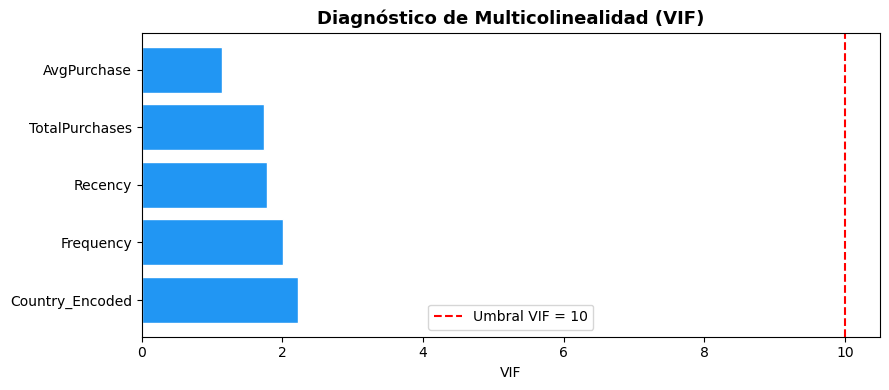


 Variables con VIF > 10 presentan multicolinealidad severa.
   Ridge (L2) estabilizará las estimaciones entre variables correlacionadas.
   Lasso (L1) puede eliminar la(s) variable(s) redundante(s) automáticamente.


In [6]:
#  Diagnóstico VIF sobre las variables predictoras (sin escalar)

feature_cols = ['Country_Encoded', 'Recency', 'Frequency', 'TotalPurchases', 'AvgPurchase']
X_vif = df_clientes[feature_cols].copy()

vif_df = pd.DataFrame({
    'Variable': feature_cols,
    'VIF': [variance_inflation_factor(X_vif.values, i)
            for i in range(X_vif.shape[1])]
}).sort_values('VIF', ascending=False).reset_index(drop=True)

print('Factor de Inflación de la Varianza (VIF) — antes del escalado:')
print(vif_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
colores_vif = ['#FF5722' if v > 10 else '#2196F3' for v in vif_df['VIF']]
ax.barh(vif_df['Variable'], vif_df['VIF'], color=colores_vif, edgecolor='white')
ax.axvline(10, color='red', linestyle='--', linewidth=1.5, label='Umbral VIF = 10')
ax.set_xlabel('VIF')
ax.set_title('Diagnóstico de Multicolinealidad (VIF)', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('Diagnostico_VIF.png', dpi=130, bbox_inches='tight')
plt.show()

print('\n Variables con VIF > 10 presentan multicolinealidad severa.')
print('   Ridge (L2) estabilizará las estimaciones entre variables correlacionadas.')
print('   Lasso (L1) puede eliminar la(s) variable(s) redundante(s) automáticamente.')

## Ejercicio 1 — Ajuste Baseline y Métricas de Matriz de Confusión (L1 y L2)

### 1.1 Plan de División y Escalado

In [7]:
#  División estratificada 80/20
#  Estratificación: preserva la proporción de churn en train y test

X = df_clientes[feature_cols].values
y = df_clientes['Churn'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=SEED
)

# Escalado: StandardScaler ajustado SOLO sobre entrenamiento
# → Se aplica (transform) al test pero NO se reajusta para evitar data leakage
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print('División del dataset:')
print(f'  Entrenamiento : {X_train_sc.shape[0]:,} muestras  (churn={y_train.mean()*100:.1f}%)')
print(f'  Prueba        : {X_test_sc.shape[0]:,} muestras  (churn={y_test.mean()*100:.1f}%)')
print('\n✅ Estratificación confirmada: la tasa de churn es idéntica en ambos conjuntos.')
print('✅ StandardScaler ajustado exclusivamente sobre el conjunto de entrenamiento.')

División del dataset:
  Entrenamiento : 3,476 muestras  (churn=33.5%)
  Prueba        : 870 muestras  (churn=33.4%)

✅ Estratificación confirmada: la tasa de churn es idéntica en ambos conjuntos.
✅ StandardScaler ajustado exclusivamente sobre el conjunto de entrenamiento.


### 1.2 Entrenamiento de Modelos Baseline

In [8]:
#  Modelos baseline con hiperparámetros razonables (C=1.0)
#  L1 → solver liblinear (único solver robusto para L1 en sklearn)
#  L2 → solver lbfgs (eficiente para problemas de tamaño moderado)
#  class_weight='balanced': compensa el desbalance moderado (~33% churn)

model_l1 = LogisticRegression(
    penalty='l1', C=1.0,
    solver='liblinear',
    class_weight='balanced',
    max_iter=1000,
    random_state=SEED
)

model_l2 = LogisticRegression(
    penalty='l2', C=1.0,
    solver='lbfgs',
    class_weight='balanced',
    max_iter=1000,
    random_state=SEED
)

model_l1.fit(X_train_sc, y_train)
model_l2.fit(X_train_sc, y_train)

print('Modelos baseline entrenados:')
print(f'  L1 — solver: liblinear  | C=1.0 | iteraciones: {model_l1.n_iter_[0]}')
print(f'  L2 — solver: lbfgs      | C=1.0 | iteraciones: {model_l2.n_iter_[0]}')

Modelos baseline entrenados:
  L1 — solver: liblinear  | C=1.0 | iteraciones: 12
  L2 — solver: lbfgs      | C=1.0 | iteraciones: 17


### 1.3 Evaluación en Conjunto de Prueba — Métricas de Matriz de Confusión

In [9]:
#  Función reutilizable para calcular métricas de confusión

def metricas_completas(y_true, y_pred, nombre='Modelo'):
    """Calcula y reporta métricas derivadas de la matriz de confusión."""
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    acc  = (tp + tn) / (tp + tn + fp + fn)
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0   # Sensibilidad / Recall
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0   # Especificidad
    f1   = f1_score(y_true, y_pred, zero_division=0)
    print(f'\n{"="*50}')
    print(f'  {nombre}')
    print(f'{"="*50}')
    print(f'  TP={tp:4d}  FP={fp:4d}')
    print(f'  FN={fn:4d}  TN={tn:4d}')
    print(f'  Exactitud (Accuracy)   : {acc:.4f}')
    print(f'  Sensibilidad (Recall)  : {sens:.4f}')
    print(f'  Especificidad          : {spec:.4f}')
    print(f'  F1-Score               : {f1:.4f}')
    return dict(modelo=nombre, TP=tp, TN=tn, FP=fp, FN=fn,
                Accuracy=acc, Sensitivity=sens, Specificity=spec, F1=f1)

y_pred_l1 = model_l1.predict(X_test_sc)
y_pred_l2 = model_l2.predict(X_test_sc)

res_l1_base = metricas_completas(y_test, y_pred_l1, 'Lasso L1 — Baseline')
res_l2_base = metricas_completas(y_test, y_pred_l2, 'Ridge L2 — Baseline')


  Lasso L1 — Baseline
  TP= 291  FP=   0
  FN=   0  TN= 579
  Exactitud (Accuracy)   : 1.0000
  Sensibilidad (Recall)  : 1.0000
  Especificidad          : 1.0000
  F1-Score               : 1.0000

  Ridge L2 — Baseline
  TP= 291  FP=   2
  FN=   0  TN= 577
  Exactitud (Accuracy)   : 0.9977
  Sensibilidad (Recall)  : 1.0000
  Especificidad          : 0.9965
  F1-Score               : 0.9966


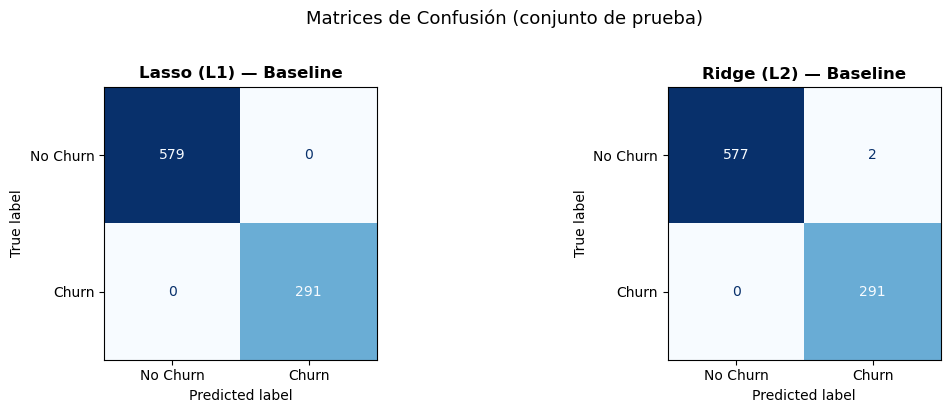

In [10]:
# Visualización de matrices de confusión
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, pred, titulo in zip(
        axes,
        [y_pred_l1, y_pred_l2],
        ['Lasso (L1) — Baseline', 'Ridge (L2) — Baseline']
):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churn'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.grid(False)
plt.suptitle('Matrices de Confusión (conjunto de prueba)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('Matrices_Confusion_Baseline.png', dpi=130, bbox_inches='tight')
plt.show()

## Ejercicio 2 — Validación Cruzada Estratificada de 10 Pliegues (sobre entrenamiento)

In [11]:
# ─────────────────────────────────────────────────────────────
#  10-Fold Stratified CV sobre el conjunto de ENTRENAMIENTO
#  El conjunto de prueba permanece intocado hasta el Ejercicio 5
#  Los mismos pliegues se usan para L1 y L2 (random_state=SEED)
# ─────────────────────────────────────────────────────────────
cv_strategy = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)

def cv_completo(model, X, y, cv, nombre):
    """Ejecuta CV 10-fold y reporta métricas por pliegue y globales."""
    resultados = {'fold': [], 'accuracy': [], 'sensitivity': [],
                  'specificity': [], 'f1': []}
    for fold, (train_idx, val_idx) in enumerate(cv.split(X, y), 1):
        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]
        model.fit(X_tr, y_tr)
        y_hat = model.predict(X_val)
        tn, fp, fn, tp = confusion_matrix(y_val, y_hat).ravel()
        resultados['fold'].append(fold)
        resultados['accuracy'].append((tp+tn)/(tp+tn+fp+fn))
        resultados['sensitivity'].append(tp/(tp+fn) if (tp+fn) > 0 else 0)
        resultados['specificity'].append(tn/(tn+fp) if (tn+fp) > 0 else 0)
        resultados['f1'].append(f1_score(y_val, y_hat, zero_division=0))
    df_cv = pd.DataFrame(resultados)
    print(f'\n{nombre} — Resultados por pliegue:')
    print(df_cv.set_index('fold').round(4).to_string())
    print(f'\n{nombre} — Resumen (media ± desv. estándar):')
    for col in ['accuracy', 'sensitivity', 'specificity', 'f1']:
        m, s = df_cv[col].mean(), df_cv[col].std()
        print(f'  {col:<14}: {m:.4f} ± {s:.4f}')
    return df_cv

cv_l1 = cv_completo(model_l1, X_train_sc, y_train, cv_strategy, 'Lasso (L1)')
cv_l2 = cv_completo(model_l2, X_train_sc, y_train, cv_strategy, 'Ridge (L2)')


Lasso (L1) — Resultados por pliegue:
      accuracy  sensitivity  specificity      f1
fold                                            
1       0.9943          1.0       0.9914  0.9915
2       1.0000          1.0       1.0000  1.0000
3       0.9971          1.0       0.9957  0.9957
4       0.9971          1.0       0.9957  0.9957
5       1.0000          1.0       1.0000  1.0000
6       0.9971          1.0       0.9957  0.9957
7       1.0000          1.0       1.0000  1.0000
8       1.0000          1.0       1.0000  1.0000
9       0.9971          1.0       0.9957  0.9957
10      1.0000          1.0       1.0000  1.0000

Lasso (L1) — Resumen (media ± desv. estándar):
  accuracy      : 0.9983 ± 0.0020
  sensitivity   : 1.0000 ± 0.0000
  specificity   : 0.9974 ± 0.0030
  f1            : 0.9974 ± 0.0030

Ridge (L2) — Resultados por pliegue:
      accuracy  sensitivity  specificity      f1
fold                                            
1       0.9971          1.0       0.9957  0.9957
2    

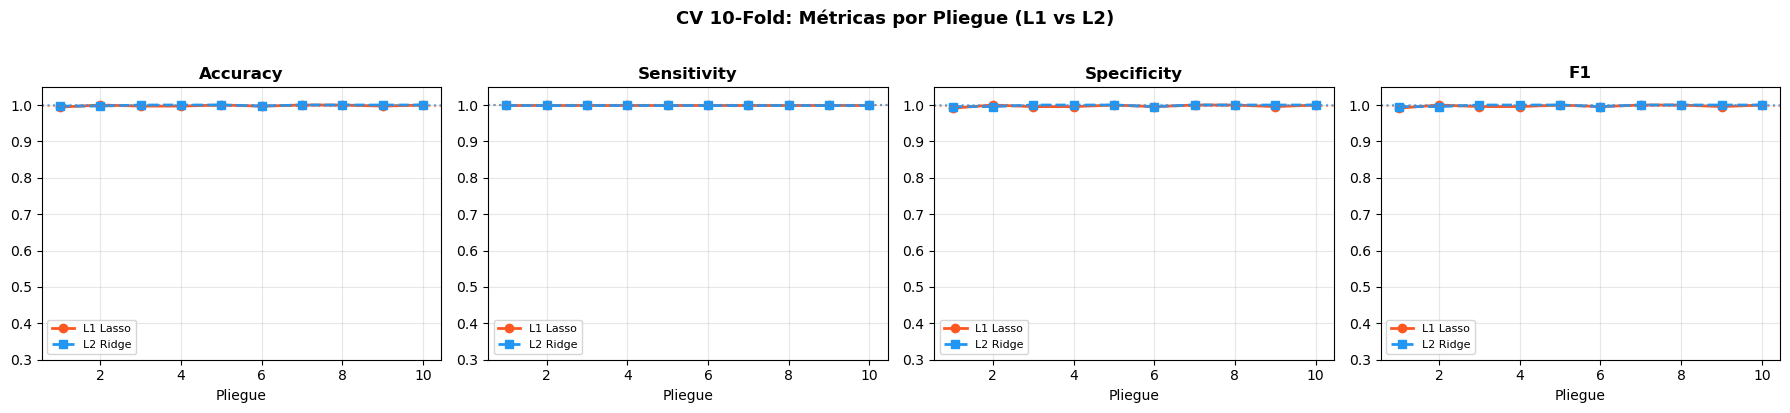

In [21]:
# Visualización comparativa por métrica y por pliegue
metrics_cv = ['accuracy', 'sensitivity', 'specificity', 'f1']
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, m in zip(axes, metrics_cv):
    ax.plot(cv_l1['fold'], cv_l1[m], 'o-', color='#FF5722', label='L1 Lasso', lw=2)
    ax.plot(cv_l2['fold'], cv_l2[m], 's--', color='#2196F3', label='L2 Ridge', lw=2)
    ax.axhline(cv_l1[m].mean(), color='#FF5722', linestyle=':', alpha=0.6)
    ax.axhline(cv_l2[m].mean(), color='#2196F3', linestyle=':', alpha=0.6)
    ax.set_title(m.capitalize(), fontweight='bold')
    ax.set_xlabel('Pliegue')
    ax.set_ylim(0.3, 1.05)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
plt.suptitle('CV 10-Fold: Métricas por Pliegue (L1 vs L2)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('CV10_Fold_Metricas.png', dpi=130, bbox_inches='tight')
plt.show()

## Ejercicio 3 — Ajuste de Hiperparámetros para Lasso (L1)

In [13]:
#  GridSearchCV — Regresión Logística L1
#  Solver: liblinear (único solver robusto para L1 en sklearn)
#  Métrica: F1 (equilibrio precision/recall, adecuada ante desbalance)
#  Validación: 5-Fold estratificado sobre el conjunto de entrenamiento

param_grid_l1 = {
    'C': [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0]
}

base_l1_gs = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    class_weight='balanced',
    max_iter=2000,
    random_state=SEED
)

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

grid_l1 = GridSearchCV(
    estimator=base_l1_gs,
    param_grid=param_grid_l1,
    cv=cv5,
    scoring='f1',
    refit=True,
    n_jobs=-1,
    verbose=0
)
grid_l1.fit(X_train_sc, y_train)

print('Ejercicio 3 — Búsqueda de hiperparámetros Lasso (L1)')
print(f'  Mejor C encontrado : {grid_l1.best_params_["C"]}')
print(f'  Mejor F1 (CV-5)    : {grid_l1.best_score_:.4f}')
print(f'  Solver utilizado   : liblinear')
print(f'  Métrica optimizada : F1-Score')

Ejercicio 3 — Búsqueda de hiperparámetros Lasso (L1)
  Mejor C encontrado : 100.0
  Mejor F1 (CV-5)    : 1.0000
  Solver utilizado   : liblinear
  Métrica optimizada : F1-Score


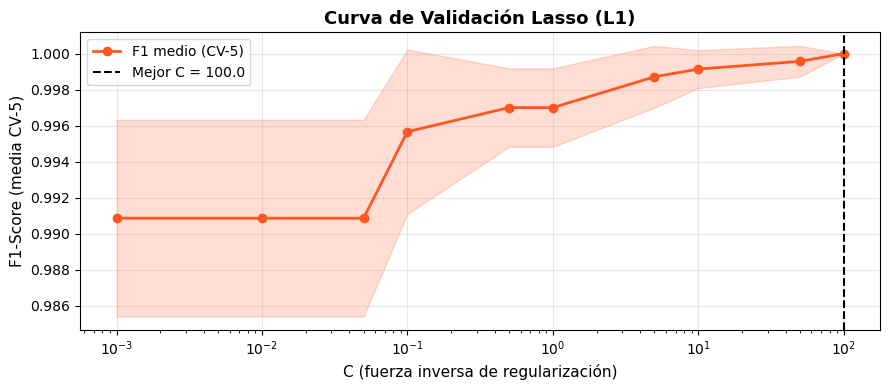

In [22]:
# Curva de validación L1
cv_results_l1 = pd.DataFrame(grid_l1.cv_results_)
fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogx(cv_results_l1['param_C'].astype(float),
            cv_results_l1['mean_test_score'], 'o-', color='#FF5722',
            label='F1 medio (CV-5)', lw=2)
ax.fill_between(
    cv_results_l1['param_C'].astype(float),
    cv_results_l1['mean_test_score'] - cv_results_l1['std_test_score'],
    cv_results_l1['mean_test_score'] + cv_results_l1['std_test_score'],
    alpha=0.2, color='#FF5722'
)
ax.axvline(grid_l1.best_params_['C'], color='black', linestyle='--',
           label=f"Mejor C = {grid_l1.best_params_['C']}")
ax.set_xlabel('C (fuerza inversa de regularización)', fontsize=11)
ax.set_ylabel('F1-Score (media CV-5)', fontsize=11)
ax.set_title('Curva de Validación Lasso (L1)', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('Curva_Validacion_L1.png', dpi=130, bbox_inches='tight')
plt.show()

## Ejercicio 4 — Ajuste de Hiperparámetros para Ridge (L2)

In [23]:
#  GridSearchCV — Regresión Logística L2
#  Solver: lbfgs (eficiente para L2, maneja bien la multicolinealidad)
#  Misma grilla, mismo criterio F1 y misma CV-5 que el Ejercicio 3
#  para mantener consistencia metodológica en la comparación

param_grid_l2 = {
    'C': [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0]
}

base_l2_gs = LogisticRegression(
    penalty='l2',
    solver='lbfgs',
    class_weight='balanced',
    max_iter=2000,
    random_state=SEED
)

grid_l2 = GridSearchCV(
    estimator=base_l2_gs,
    param_grid=param_grid_l2,
    cv=cv5,
    scoring='f1',
    refit=True,
    n_jobs=-1,
    verbose=0
)
grid_l2.fit(X_train_sc, y_train)

print('Búsqueda de hiperparámetros Ridge (L2)')
print(f'  Mejor C encontrado : {grid_l2.best_params_["C"]}')
print(f'  Mejor F1 (CV-5)    : {grid_l2.best_score_:.4f}')
print(f'  Solver utilizado   : lbfgs')
print(f'  Métrica optimizada : F1-Score (coherente con Ejercicio 3)')

Búsqueda de hiperparámetros Ridge (L2)
  Mejor C encontrado : 1.0
  Mejor F1 (CV-5)    : 0.9983
  Solver utilizado   : lbfgs
  Métrica optimizada : F1-Score (coherente con Ejercicio 3)


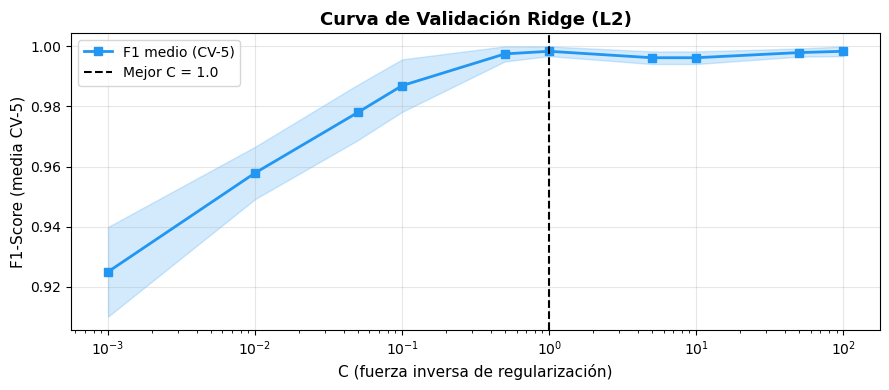

In [24]:
# Curva de validación L2
cv_results_l2 = pd.DataFrame(grid_l2.cv_results_)
fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogx(cv_results_l2['param_C'].astype(float),
            cv_results_l2['mean_test_score'], 's-', color='#2196F3',
            label='F1 medio (CV-5)', lw=2)
ax.fill_between(
    cv_results_l2['param_C'].astype(float),
    cv_results_l2['mean_test_score'] - cv_results_l2['std_test_score'],
    cv_results_l2['mean_test_score'] + cv_results_l2['std_test_score'],
    alpha=0.2, color='#2196F3'
)
ax.axvline(grid_l2.best_params_['C'], color='black', linestyle='--',
           label=f"Mejor C = {grid_l2.best_params_['C']}")
ax.set_xlabel('C (fuerza inversa de regularización)', fontsize=11)
ax.set_ylabel('F1-Score (media CV-5)', fontsize=11)
ax.set_title('Curva de Validación Ridge (L2)', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('Curva_Validacion_L2.png', dpi=130, bbox_inches='tight')
plt.show()

## Ejercicio 5 — Entrenamiento Final y Evaluación Única sobre el Conjunto de Prueba

In [17]:
#  Los best_estimator_ de GridSearchCV ya fueron reentrenados
#  sobre TODO el conjunto de entrenamiento gracias a refit=True
#  → No es necesario reentrenar manualmente

best_l1 = grid_l1.best_estimator_
best_l2 = grid_l2.best_estimator_

print(f'Modelo final L1 — C óptimo: {grid_l1.best_params_["C"]} | solver: liblinear')
print(f'Modelo final L2 — C óptimo: {grid_l2.best_params_["C"]} | solver: lbfgs')
print('\n  EVALUACIÓN ÚNICA: el conjunto de prueba se usa por primera vez aquí.')

y_pred_best_l1 = best_l1.predict(X_test_sc)
y_pred_best_l2 = best_l2.predict(X_test_sc)

final_l1 = metricas_completas(y_test, y_pred_best_l1, 'Lasso (L1) — FINAL')
final_l2 = metricas_completas(y_test, y_pred_best_l2, 'Ridge (L2) — FINAL')

Modelo final L1 — C óptimo: 100.0 | solver: liblinear
Modelo final L2 — C óptimo: 1.0 | solver: lbfgs

  EVALUACIÓN ÚNICA: el conjunto de prueba se usa por primera vez aquí.

  Lasso (L1) — FINAL
  TP= 291  FP=   0
  FN=   0  TN= 579
  Exactitud (Accuracy)   : 1.0000
  Sensibilidad (Recall)  : 1.0000
  Especificidad          : 1.0000
  F1-Score               : 1.0000

  Ridge (L2) — FINAL
  TP= 291  FP=   2
  FN=   0  TN= 577
  Exactitud (Accuracy)   : 0.9977
  Sensibilidad (Recall)  : 1.0000
  Especificidad          : 0.9965
  F1-Score               : 0.9966



  TABLA COMPARATIVA FINAL — L1 vs L2 (conjunto de prueba)
                    Accuracy  Sensitivity  Specificity      F1
modelo                                                        
Lasso (L1) — FINAL    1.0000          1.0       1.0000  1.0000
Ridge (L2) — FINAL    0.9977          1.0       0.9965  0.9966


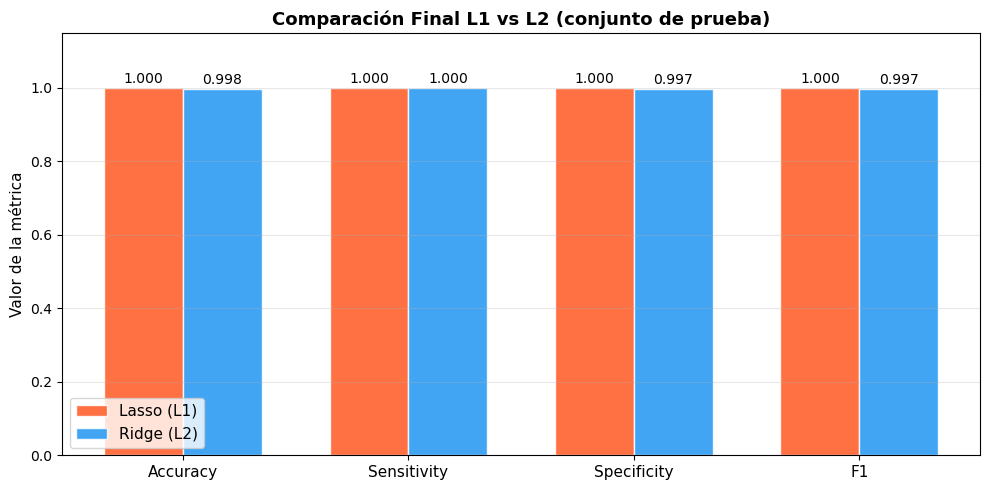

In [25]:
# Tabla comparativa de métricas finales
tabla_final = pd.DataFrame([final_l1, final_l2]).set_index('modelo')
print('\n' + '='*62)
print('  TABLA COMPARATIVA FINAL — L1 vs L2 (conjunto de prueba)')
print('='*62)
print(tabla_final[['Accuracy','Sensitivity','Specificity','F1']].round(4).to_string())

# Gráfico comparativo de métricas finales
metrics_names = ['Accuracy', 'Sensitivity', 'Specificity', 'F1']
x = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, [final_l1[m] for m in metrics_names],
               width, label='Lasso (L1)', color='#FF5722', alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + width/2, [final_l2[m] for m in metrics_names],
               width, label='Ridge (L2)', color='#2196F3', alpha=0.85, edgecolor='white')

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(metrics_names, fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Valor de la métrica', fontsize=11)
ax.set_title('Comparación Final L1 vs L2 (conjunto de prueba)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('Comparacion_Final_L1_L2.png', dpi=130, bbox_inches='tight')
plt.show()

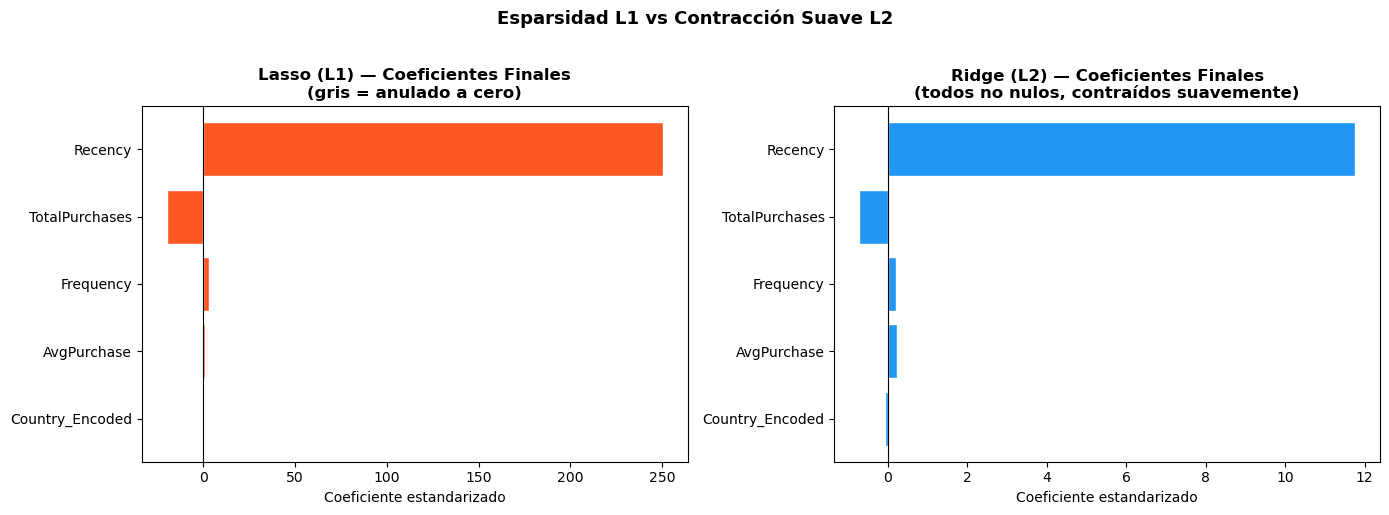

Variables anuladas por L1 (coef = 0): 0 de 5
Variables retenidas por L1           : 5
Todas las variables retenidas por L2 : 5


In [26]:
#  Análisis de coeficientes: esparsidad (L1) vs contracción (L2)

coef_df = pd.DataFrame({
    'Variable': feature_cols,
    'Coef_L1':  best_l1.coef_[0],
    'Coef_L2':  best_l2.coef_[0]
}).sort_values('Coef_L1', key=abs, ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colores_l1 = ['#FF5722' if v != 0 else '#BDBDBD' for v in coef_df['Coef_L1']]
colores_l2 = ['#2196F3' for _ in coef_df['Coef_L2']]

axes[0].barh(coef_df['Variable'], coef_df['Coef_L1'],
             color=colores_l1, edgecolor='white')
axes[0].axvline(0, color='black', lw=0.8)
axes[0].set_title('Lasso (L1) — Coeficientes Finales\n(gris = anulado a cero)',
                   fontsize=12, fontweight='bold')
axes[0].set_xlabel('Coeficiente estandarizado')

axes[1].barh(coef_df['Variable'], coef_df['Coef_L2'],
             color=colores_l2, edgecolor='white')
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_title('Ridge (L2) — Coeficientes Finales\n(todos no nulos, contraídos suavemente)',
                   fontsize=12, fontweight='bold')
axes[1].set_xlabel('Coeficiente estandarizado')

plt.suptitle('Esparsidad L1 vs Contracción Suave L2',
             fontsize=13, y=1.02, fontweight='bold')
plt.tight_layout()
plt.savefig('Coeficientes_L1_vs_L2.png', dpi=130, bbox_inches='tight')
plt.show()

ceros_l1 = (coef_df['Coef_L1'] == 0).sum()
print(f'Variables anuladas por L1 (coef = 0): {ceros_l1} de {len(feature_cols)}')
print(f'Variables retenidas por L1           : {len(feature_cols) - ceros_l1}')
print(f'Todas las variables retenidas por L2 : {(coef_df["Coef_L2"] != 0).sum()}')